In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

In [2]:
# Define tickers
crypto_tickers = ['ETH-USD', 'LTC-USD', 'XRP-USD', 'DOGE-USD', 'NMC-USD', 'BTC-USD']
forex_tickers = ['GBPUSD=X', 'JPY=X', 'AUDUSD=X', 'CHF=X', 'EURGBP=X', 'EURUSD=X']
bonds_tickers = ["IEI", "TLT", "BNDX", "LQD", "HYG", "^TNX"]
equities_tickers = ["^FTSE", "^N225", "^IXIC", "EEM", "VTV", "^GSPC"]
derivatives_tickers = ['ES=F', 'NQ=F', '^VIX', 'GC=F', 'CL=F', 'BTC=F']
tickers = crypto_tickers + forex_tickers + bonds_tickers + equities_tickers + derivatives_tickers

# Download daily data
# Modified download call
raw_data = yf.download(tickers, start="2015-09-01", end="2025-08-30", auto_adjust=False)['Adj Close']

[*********************100%***********************]  30 of 30 completed


In [3]:
returns = np.log(raw_data / raw_data.shift(1)).dropna() * 100
returns.head()
# returns.tail()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Ticker,AUDUSD=X,BNDX,BTC-USD,BTC=F,CHF=X,CL=F,DOGE-USD,EEM,ES=F,ETH-USD,...,NQ=F,TLT,VTV,XRP-USD,^FTSE,^GSPC,^IXIC,^N225,^TNX,^VIX
Date,,,,,,,,,,,,,,,,,,,,,
2017-12-19,0.191466,-0.344548,-7.254291,-4.826674,-0.556520,0.523469,-12.695760,-0.529742,-0.390444,3.969514,...,-0.529305,-1.305813,-0.290061,1.637336,0.094159,-0.323550,-0.442877,-0.147563,2.925032,5.113589
2017-12-20,-0.160855,-0.036302,-6.700506,-6.585807,-0.014202,1.090450,16.178628,0.131052,-0.093188,-0.940156,...,-0.180912,-1.113537,0.037464,-1.951669,-0.250840,-0.082824,-0.041511,0.103675,1.370986,-3.139493
2017-12-21,0.245206,-0.090909,-5.069001,-10.575183,0.085209,0.463720,10.858303,0.652744,0.232807,0.241075,...,0.050072,0.581176,0.317099,43.017059,1.041701,0.198369,0.063188,-0.111986,-0.642832,-1.034139
2017-12-22,0.461407,0.018165,-13.322322,-8.115770,0.232934,0.188309,-20.413347,0.842261,-0.065131,-19.609459,...,-0.131011,0.136341,-0.009375,-4.700309,-0.148714,-0.045827,-0.077555,0.160197,0.161093,2.869047
2017-12-28,0.572911,-0.147160,-8.097705,-6.649187,-0.394836,0.334786,-4.448247,0.684648,0.009309,-3.443179,...,-0.120153,-0.086808,0.262855,2.207457,0.028861,0.183232,0.155806,-0.556867,0.742880,-2.808901


In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

# --- 1. DATA ACQUISITION ---
def get_all_market_data():
    # Explicitly defined lists as per your requirements
    crypto = ['ETH-USD', 'LTC-USD', 'XRP-USD', 'DOGE-USD', 'NMC-USD', 'BTC-USD']
    forex = ['GBPUSD=X', 'JPY=X', 'AUDUSD=X', 'CHF=X', 'EURGBP=X', 'EURUSD=X']
    bonds = ["IEI", "TLT", "BNDX", "LQD", "HYG", "^TNX"]
    equities = ["^FTSE", "^N225", "^IXIC", "EEM", "VTV", "^GSPC"]
    derivatives = ['ES=F', 'NQ=F', '^VIX', 'GC=F', 'CL=F', 'BTC=F']

    all_tickers = crypto + forex + bonds + equities + derivatives

    # Downloading data
    raw = yf.download(all_tickers, start="2015-09-01", end="2025-08-31", auto_adjust=True)

    # Use 'Close' price, forward fill missing values, and drop remaining NaNs
    prices = raw['Close'].ffill().dropna()

    # Log Returns Calculation: Log(P_t / P_{t-1}) * 100
    returns = (np.log(prices / prices.shift(1)) * 100).dropna()
    return returns, crypto, forex, bonds, equities, derivatives

returns_all, crypto_list, forex_list, bond_list, equity_list, deriv_list = get_all_market_data()

# --- 2. FULL DIAGNOSTIC & DESCRIPTIVE RUNNER ---
def run_full_diagnostics(df, c_list, f_list, b_list, e_list, d_list):
    stats_list = []

    for col in df.columns:
        if df[col].empty: continue

        # --- Descriptive Statistics ---
        desc = df[col].describe()
        skewness = df[col].skew()
        kurt = df[col].kurtosis()

        # --- Diagnostic Tests ---
        # ADF Test (Stationarity)
        adf_p = adfuller(df[col])[1]

        # Engle ARCH-LM Test (Volatility Clustering)
        arch_p = het_arch(df[col], nlags=12)[1]

        # --- REFACTORED: Explicit Market Categorization ---
        if col in c_list:
            market_label = 'Crypto'
        elif col in f_list:
            market_label = 'Forex'
        elif col in b_list:
            market_label = 'Bond'
        elif col in e_list:
            market_label = 'Equity'
        elif col in d_list:
            market_label = 'Derivative'
        else:
            market_label = 'Other'

        stats_list.append({
            'Asset': col,
            'Market': market_label,
            'Mean (%)': desc['mean'],
            'StdDev (%)': desc['std'],
            'Skew': skewness,
            'Kurtosis': kurt,
            'ADF_p': adf_p,
            'ARCH_p': arch_p
        })

    return pd.DataFrame(stats_list)

# Execute
diagnostic_results = run_full_diagnostics(returns_all, crypto_list, forex_list, bond_list, equity_list, deriv_list)

# Sorting for a systematic presentation in your report
diagnostic_results = diagnostic_results.sort_values(['Market', 'Asset'])

print("\n--- Finalized 5-Market Diagnostic & Descriptive Summary ---")
print(diagnostic_results.round(4).to_string(index=False))

# --- 3. SYSTEMATIC SAVING ---
# Saving as CSV so you can open directly in Excel for your thesis tables
diagnostic_results.to_csv("Descriptive_Statistics_Table_1.csv", index=False)

[*********************100%***********************]  30 of 30 completed
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)



--- Finalized 5-Market Diagnostic & Descriptive Summary ---
   Asset     Market  Mean (%)  StdDev (%)    Skew  Kurtosis  ADF_p  ARCH_p
    BNDX       Bond    0.0045      0.2273 -0.6025   11.6750    0.0     0.0
     HYG       Bond    0.0128      0.4695 -0.0644   37.3017    0.0     0.0
     IEI       Bond    0.0044      0.2205  0.3795    5.6782    0.0     0.0
     LQD       Bond    0.0062      0.4979  0.3778   36.9480    0.0     0.0
     TLT       Bond   -0.0071      0.8337  0.0705    8.1188    0.0     0.0
    ^TNX       Bond    0.0251      2.7052  0.3490   47.7296    0.0     0.0
 BTC-USD     Crypto    0.0635      3.5104 -0.9417   13.8863    0.0     0.0
DOGE-USD     Crypto    0.1266      6.8135  4.7529   98.5113    0.0     0.0
 ETH-USD     Crypto    0.0625      4.5557 -0.8818   10.9124    0.0     0.0
 LTC-USD     Crypto   -0.0404      4.8588 -0.5167    7.9425    0.0     0.0
 NMC-USD     Crypto   -0.0455      7.8798 -0.9870   29.3097    0.0     0.0
 XRP-USD     Crypto    0.0470      5.56

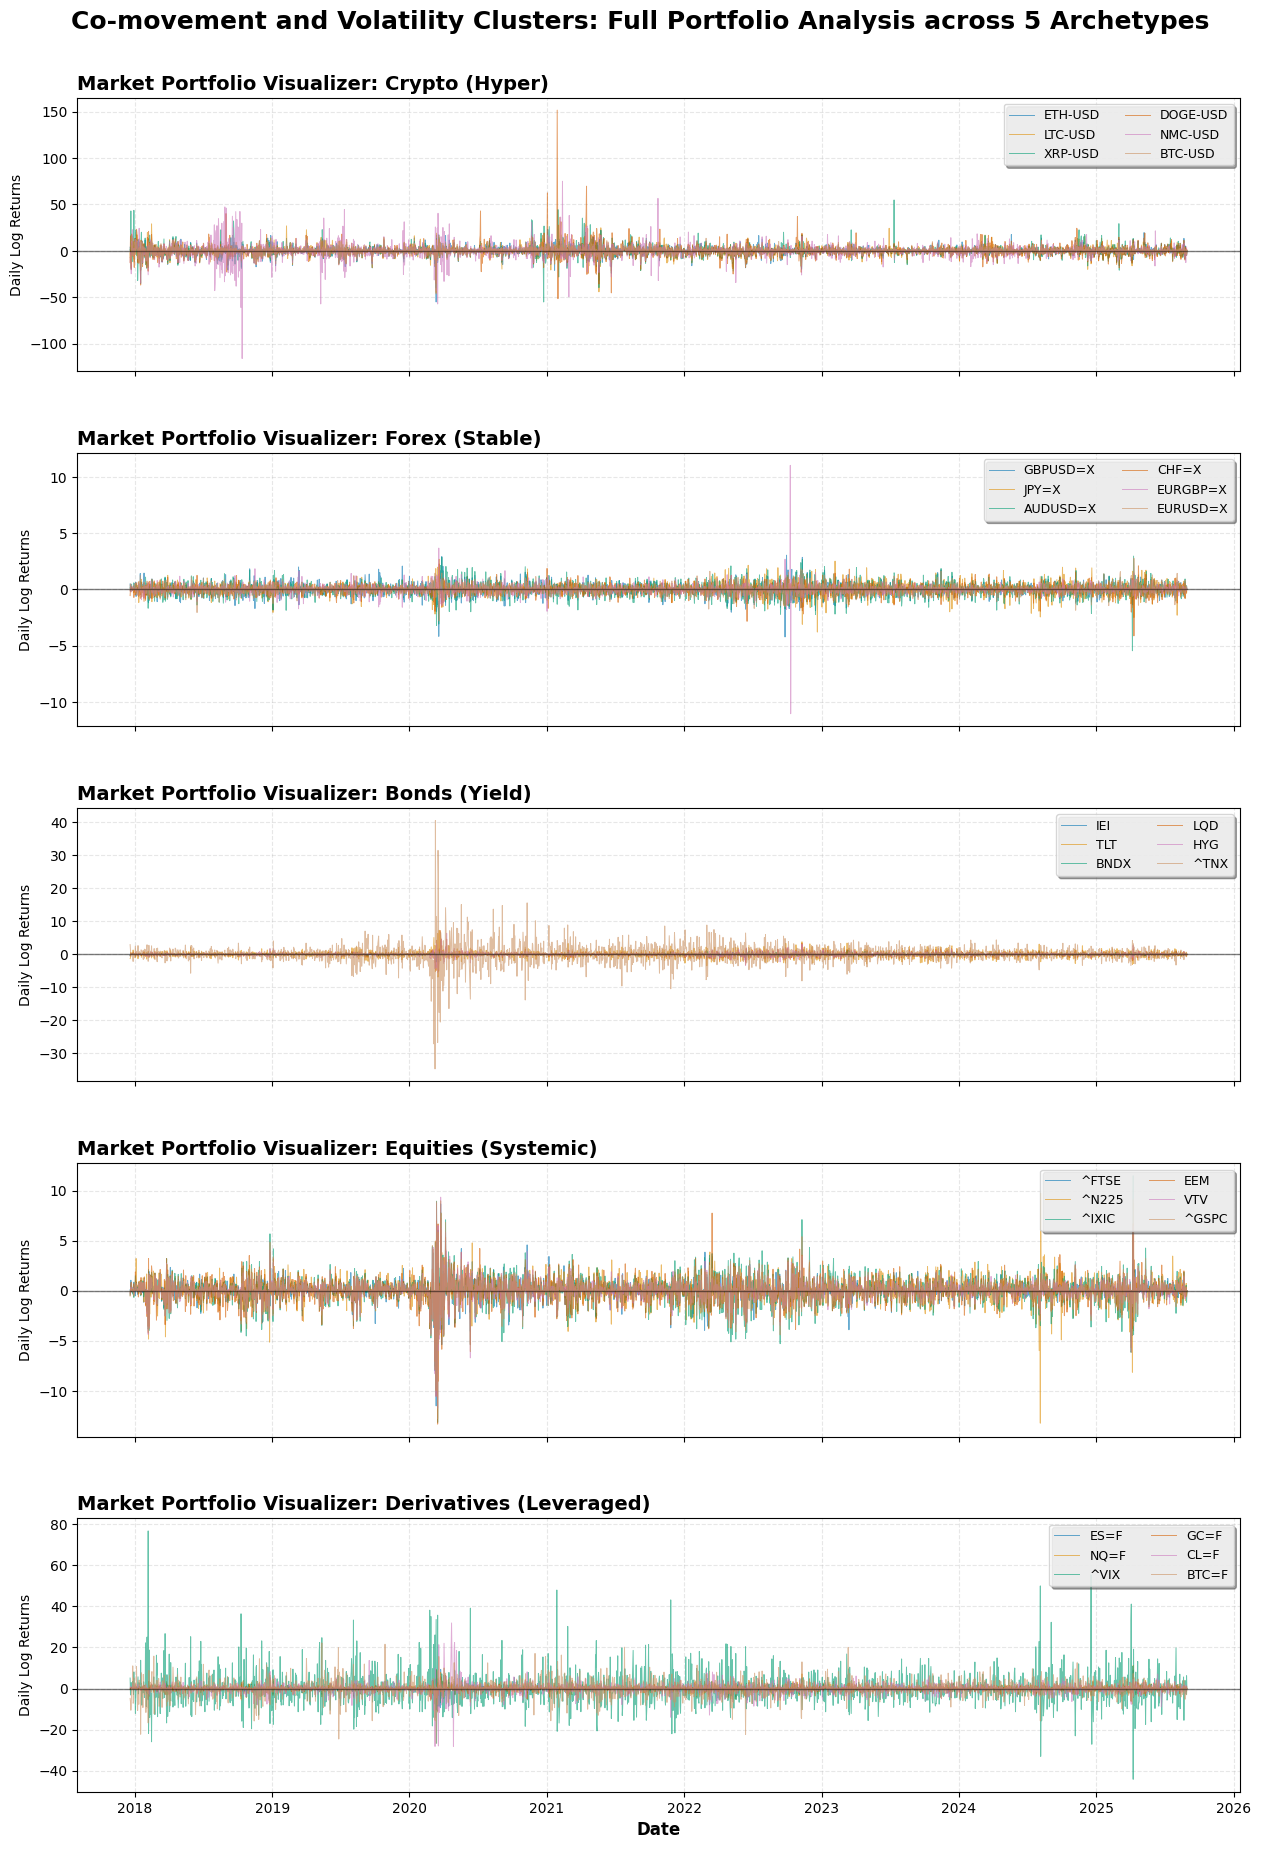

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the asset groups exactly as they are in your environment
# (These lists are already verified and correct)
market_groups = {
    'Crypto (Hyper)': ['ETH-USD', 'LTC-USD', 'XRP-USD', 'DOGE-USD', 'NMC-USD', 'BTC-USD'],
    'Forex (Stable)': ['GBPUSD=X', 'JPY=X', 'AUDUSD=X', 'CHF=X', 'EURGBP=X', 'EURUSD=X'],
    'Bonds (Yield)': ["IEI", "TLT", "BNDX", "LQD", "HYG", "^TNX"],
    'Equities (Systemic)': ["^FTSE", "^N225", "^IXIC", "EEM", "VTV", "^GSPC"],
    'Derivatives (Leveraged)': ['ES=F', 'NQ=F', '^VIX', 'GC=F', 'CL=F', 'BTC=F']
}

# 2. Setup the figure with 5 panes (one for each market)
fig, axes = plt.subplots(5, 1, figsize=(15, 22), sharex=True)
plt.subplots_adjust(hspace=0.3)

# Use a bright, high-contrast color palette for the 6 distinct asset lines
# (The 'colorblind' palette is good for academic work)
asset_colors = sns.color_palette("colorblind", 6)

for i, (market_name, tickers) in enumerate(market_groups.items()):
    ax = axes[i]

    # --- Overlay all 6 assets in a single pane ---
    for j, ticker in enumerate(tickers):
        if ticker in returns_all.columns:
            # We keep the line thin (lw=0.7) and slightly transparent (alpha=0.6)
            # so they all blend together visually, making the clusters pop out
            ax.plot(returns_all.index, returns_all[ticker],
                    label=ticker,
                    color=asset_colors[j],
                    lw=0.7,
                    alpha=0.6)
        else:
            print(f"Warning: {ticker} not found in returns_all data")

    # --- Pane Aesthetics ---
    ax.set_title(f"Market Portfolio Visualizer: {market_name}", fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel("Daily Log Returns")

    # Place a clean, 2-column legend to the top-right of each pane
    ax.legend(loc='upper right', ncol=2, fontsize=9, frameon=True, shadow=True, framealpha=0.8)

    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(0, color='black', lw=1, alpha=0.5)

# --- Global Formatting ---
axes[-1].set_xlabel("Date", fontsize=12, fontweight='bold')
plt.suptitle("Co-movement and Volatility Clusters: Full Portfolio Analysis across 5 Archetypes",
             fontsize=18, y=0.92, fontweight='bold')

# --- Systematically Save Results ---
plt.savefig("Full_Portfolio_Market_Visualization_5_Panes.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
%load_ext Cython

In [7]:
%%cython --cplus
# distutils: language = c++

import numpy as np
cimport numpy as cnp
from libc.math cimport log, exp, sqrt, M_PI

cdef double NORMAL_CONST = 1.0 / sqrt(2.0 * M_PI)

# ── LCG random number generator (unsigned 32-bit, avoids sign-bit issues) ──
cdef unsigned int lcg_rand(unsigned int *seed) nogil:
    seed[0] = seed[0] * 1664525u + 1013904223u
    return seed[0]

cdef double c_rand_unit(unsigned int *seed) nogil:
    return <double>lcg_rand(seed) / <double>4294967295.0

cdef inline double fast_norm_pdf(double x, double mu, double sigma) nogil:
    if sigma <= 1e-10: return 0.0
    cdef double z = (x - mu) / sigma
    return (NORMAL_CONST / sigma) * exp(-0.5 * z * z)

def cpp_log_likelihood(double[:] y, double[:] x, double[:] params, int method_code):
    cdef int T = y.shape[0]

    # ── Parameter vector [c1,c2, g1,g2, w1,a1,b1, w2,a2,b2, p11,p22] ──────
    cdef double c1 = params[0], c2 = params[1]
    cdef double g1 = params[2], g2 = params[3]
    cdef double w1 = params[4], a1 = params[5], b1 = params[6]
    cdef double w2 = params[7], a2 = params[8], b2 = params[9]
    cdef double p11 = params[10], p22 = params[11]

    # ── State variables ──────────────────────────────────────────────────────
    cdef double v1 = 1.0, v2 = 1.0
    cdef double p_filt1 = 0.5, p_filt2 = 0.5
    cdef double p_pred1, p_pred2
    cdef double loglik = 0.0
    cdef int t, i, j
    cdef unsigned int seed = 42

    # ── Gauss-Hermite (5-point) quadrature constants ─────────────────────────
    cdef double[5] nodes   = [-2.85697, -1.35562, 0.0, 1.35562, 2.85697]
    cdef double[5] weights = [ 0.01125,  0.22207, 0.53333, 0.22207, 0.01125]

    # ── Particle filter arrays (discrete 0/1 state particles) ───────────────
    cdef int N = 1000
    cdef int[:] particles     = np.where(np.random.uniform(0, 1, N) < 0.5,
                                          0, 1).astype(np.int32)
    cdef int[:] new_particles = np.zeros(N, dtype=np.int32)
    cdef double[:] pweights   = np.empty(N, dtype=np.float64)
    cdef double[:] pcumsum    = np.empty(N, dtype=np.float64)

    # ── Working variables ────────────────────────────────────────────────────
    cdef double mu1, mu2, mu1_prev, mu2_prev, inn1, inn2
    cdef double v_avg, v_quad, f1, f2, lik_t, sig_t, w_sum, u_sys, target

    # ── Pre-sample mean initialisation (use x[0] as proxy for x[-1]) ────────
    mu1_prev = c1 + g1 * x[0]
    mu2_prev = c2 + g2 * x[0]

    for t in range(1, T):

        # ── FIX 2: Mean for y[t] uses x[t-1] (strictly lagged exogenous) ────
        mu1 = c1 + g1 * x[t-1]
        mu2 = c2 + g2 * x[t-1]

        # ── FIX 3: Innovations at t-1 use the mean from the previous step ───
        inn1 = y[t-1] - mu1_prev
        inn2 = y[t-1] - mu2_prev

        # ── FIX 1 & 4: One-step-ahead PREDICTED probabilities (Hamilton) ────
        p_pred1 = p_filt1 * p11 + p_filt2 * (1.0 - p22)
        p_pred2 = 1.0 - p_pred1

        # ── Variance update ──────────────────────────────────────────────────

        if method_code == 0:   # GRAY (1996) — collapse uses PREDICTED probs
            # FIX 4: p_pred1/p_pred2 replace the old p_filt1/p_filt2 here
            v_avg = (p_pred1 * (mu1 * mu1 + v1) + p_pred2 * (mu2 * mu2 + v2)) \
                  - (p_pred1 * mu1 + p_pred2 * mu2) ** 2
            v_avg = max(v_avg, 1e-10)
            v1 = max(w1 + a1 * inn1 * inn1 + b1 * v_avg, 1e-10)
            v2 = max(w2 + a2 * inn2 * inn2 + b2 * v_avg, 1e-10)

        elif method_code == 1: # PLUGIN — each regime owns its variance path
            v1 = max(w1 + a1 * inn1 * inn1 + b1 * v1, 1e-10)
            v2 = max(w2 + a2 * inn2 * inn2 + b2 * v2, 1e-10)

        elif method_code == 2: # QUADRATURE — GH quadrature over Gray collapsed variance
            # Step 1: compute Gray's collapsed variance (h_tilde) as the quadrature centre
            v_avg = (p_pred1 * (mu1 * mu1 + v1) + p_pred2 * (mu2 * mu2 + v2)) \
                  - (p_pred1 * mu1 + p_pred2 * mu2) ** 2
            v_avg = max(v_avg, 1e-10)
            # Step 2: GH nodes scaled by sqrt(v_avg) — correct units (variance scale)
            sig_t = sqrt(v_avg)
            v_quad = 0.0
            for i in range(5):
                v_quad += weights[i] * max(v_avg + sig_t * nodes[i], 1e-10)
            # Step 3: GARCH update using the GH-integrated collapsed variance
            v1 = max(w1 + a1 * inn1 * inn1 + b1 * v_quad, 1e-10)
            v2 = max(w2 + a2 * inn2 * inn2 + b2 * v_quad, 1e-10)

        # ── Likelihood & filter update ───────────────────────────────────────

        if method_code != 3:
            f1 = fast_norm_pdf(y[t], mu1, sqrt(v1))
            f2 = fast_norm_pdf(y[t], mu2, sqrt(v2))

            # FIX 1: Use p_pred1/p_pred2; weights now always sum to 1.0
            lik_t = p_pred1 * f1 + p_pred2 * f2
            loglik += log(max(lik_t, 1e-300))

            # Bayes update: posterior = predicted x likelihood / marginal
            p_filt1 = p_pred1 * f1 / max(lik_t, 1e-300)
            p_filt2 = 1.0 - p_filt1

        else:  # ── PARTICLE FILTER (Sequential Monte Carlo) ─────────────────
            # FIX 5a: Propagate discrete 0/1 state particles
            w_sum = 0.0
            for i in range(N):
                if particles[i] == 0:
                    new_particles[i] = 0 if c_rand_unit(&seed) < p11 else 1
                else:
                    new_particles[i] = 1 if c_rand_unit(&seed) < p22 else 0

                # FIX 5b: Importance weight = p(y[t] | propagated state)
                if new_particles[i] == 0:
                    sig_t = sqrt(max(w1 + a1 * inn1 * inn1 + b1 * v1, 1e-10))
                    pweights[i] = fast_norm_pdf(y[t], mu1, sig_t)
                else:
                    sig_t = sqrt(max(w2 + a2 * inn2 * inn2 + b2 * v2, 1e-10))
                    pweights[i] = fast_norm_pdf(y[t], mu2, sig_t)
                w_sum += pweights[i]

            lik_t = w_sum / N
            loglik += log(max(lik_t, 1e-300))

            # Normalize weights
            if w_sum > 1e-300:
                for i in range(N): pweights[i] /= w_sum
            else:
                for i in range(N): pweights[i] = 1.0 / N

            # FIX 5c: Systematic resampling — builds CDF then draws once
            pcumsum[0] = pweights[0]
            for i in range(1, N):
                pcumsum[i] = pcumsum[i - 1] + pweights[i]

            u_sys = c_rand_unit(&seed) / N
            j = 0
            for i in range(N):
                target = u_sys + (<double>i) / N
                while j < N - 1 and pcumsum[j] < target:
                    j += 1
                particles[i] = new_particles[j]

            # Filter probability from resampled particle distribution
            w_sum = 0.0
            for i in range(N):
                if particles[i] == 0: w_sum += 1.0
            p_filt1 = w_sum / N
            p_filt2 = 1.0 - p_filt1

            # FIX 5d: Update variance state for next step (plugin approximation)
            v1 = max(w1 + a1 * inn1 * inn1 + b1 * v1, 1e-10)
            v2 = max(w2 + a2 * inn2 * inn2 + b2 * v2, 1e-10)

        # ── Carry forward current means for next iteration's innovation ──────
        mu1_prev = mu1
        mu2_prev = mu2

    return -loglik


Content of stderr:
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /root/.cache/ipython/cython/_cython_magic_2d187965b93281cbcbdfd886f09e75f26677f7df.cpp:1262:
/usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~

In [8]:
class MSGARCH_CPP_Engine:
    def __init__(self, y, x=None, method='gray'):
        # 1. Robust Type Conversion for y (Target Asset)
        self.y = y.values.astype(np.float64) if hasattr(y, 'values') else np.array(y, dtype=np.float64)

        # 2. Robust Type Conversion for x (Exogenous Pivot)
        if x is not None:
            self.x = x.values.astype(np.float64) if hasattr(x, 'values') else np.array(x, dtype=np.float64)
        else:
            # Symmetrical structure: If No-Exo, fill with zeros of same length as y
            self.x = np.zeros_like(self.y)

        # 3. Defensive Check: Ensure arrays are not empty before passing to Cython
        if len(self.y) == 0 or len(self.x) == 0:
            raise ValueError("Input data (y or x) is empty. Check data download/alignment.")

        # 4. Method mapping for the C++ switch statement
        # 0: Gray, 1: Plugin, 2: Quadrature, 3: Particle
        m_map = {'gray': 0, 'plugin': 1, 'quadrature': 2, 'particle': 3}
        self.method_code = m_map.get(method.lower(), 0)

    def log_likelihood(self, params):
        """
        Expects a 12-parameter vector:
        [c1, c2, g1, g2, w1, a1, b1, w2, a2, b2, p11, p22]
        """
        # Convert params to float64 for C++ compatibility
        params_fixed = np.ascontiguousarray(params, dtype=np.float64)

        # 1. Stationarity Constraints (GARCH stability: alpha + beta < 1)
        # Regime 1: params[5] + params[6]
        # Regime 2: params[8] + params[9]
        if (params_fixed[5] + params_fixed[6] >= 1.0) or (params_fixed[8] + params_fixed[9] >= 1.0):
            return 1e10 # Penalize unstable parameter combinations

        # 2. Probability Constraints (0 < p < 1)
        # Though usually handled by L-BFGS-B bounds, we protect the log() here
        if (params_fixed[10] <= 0 or params_fixed[10] >= 1 or
            params_fixed[11] <= 0 or params_fixed[11] >= 1):
            return 1e10

        # 3. Variance Positivity Constraints (omega > 0)
        if params_fixed[4] <= 0 or params_fixed[7] <= 0:
            return 1e10

        # Pass to the optimized Cython/C++ engine
        return cpp_log_likelihood(self.y, self.x, params_fixed, self.method_code)

In [9]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import minimize

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def run_systematic_experiment(returns_df):
    methods = ['gray', 'plugin', 'quadrature', 'particle']
    param_names = ['c1','c2','g1','g2','w1','a1','b1','w2','a2','b2','p11','p22']

    configs = [
        {'targets': ['ETH-USD','LTC-USD','XRP-USD','DOGE-USD','NMC-USD'],
         'pivot': 'BTC-USD', 'label': 'Crypto'},
        {'targets': ['GBPUSD=X','JPY=X','AUDUSD=X','CHF=X','EURGBP=X'],
         'pivot': 'EURUSD=X', 'label': 'Forex'},
        {'targets': ['IEI','TLT','BNDX','LQD','HYG'],
         'pivot': '^TNX', 'label': 'Bonds'},
        {'targets': ['^FTSE','^N225','^IXIC','EEM','VTV'],
         'pivot': '^GSPC', 'label': 'Equities'},
        {'targets': ['ES=F', 'NQ=F', '^VIX', 'GC=F', 'CL=F'],
         'pivot': 'BTC=F', 'label': 'Derivatives'}
    ]

    # Multiple starting points guard against local-minima in the non-convex likelihood
    INITS_BASE = [
        [0, 0, 0, 0,  0.10, 0.10, 0.70,  0.20, 0.20, 0.60,  0.90, 0.90],
        [0, 0, 0, 0,  0.30, 0.05, 0.85,  0.10, 0.08, 0.78,  0.95, 0.80],
        [0, 0, 0, 0,  0.50, 0.15, 0.60,  0.40, 0.20, 0.55,  0.75, 0.95],
    ]
    INITS_EXO = [
        [0, 0,  0.10, 0.10,  0.10, 0.10, 0.70,  0.20, 0.20, 0.60,  0.90, 0.90],
        [0, 0,  0.05, 0.05,  0.30, 0.05, 0.85,  0.10, 0.08, 0.78,  0.95, 0.80],
        [0, 0, -0.10, 0.20,  0.50, 0.15, 0.60,  0.40, 0.20, 0.55,  0.75, 0.95],
    ]

    def best_minimize(engine, inits, bounds):
        best = None
        for init in inits:
            r = minimize(engine.log_likelihood, init, method='L-BFGS-B', bounds=bounds)
            if best is None or r.fun < best.fun:
                best = r
        return best

    BOUNDS_BASE = [(-5,5),(-5,5), (0,0),(0,0),
                   (1e-4,2),(1e-4,0.9),(1e-4,0.9),
                   (1e-4,2),(1e-4,0.9),(1e-4,0.9),
                   (0.01,0.99),(0.01,0.99)]
    BOUNDS_EXO  = [(-5,5),(-5,5), (-5,5),(-5,5),
                   (1e-4,2),(1e-4,0.9),(1e-4,0.9),
                   (1e-4,2),(1e-4,0.9),(1e-4,0.9),
                   (0.01,0.99),(0.01,0.99)]

    for config in configs:
        market = config['label']
        baseline_params, baseline_diag = [], []
        exo_params, exo_diag = [], []

        # ── PHASE 1: BASELINE (6 assets; g1=g2=0 forced by bounds) ──────────
        for asset in config['targets'] + [config['pivot']]:
            if asset not in returns_df.columns:
                continue
            T_obs = int(returns_df[asset].dropna().shape[0])
            for m_name in methods:
                print(f"BASELINE  {market} | {asset} | {m_name}")
                engine = MSGARCH_CPP_Engine(returns_df[asset], x=None, method=m_name)
                res = best_minimize(engine, INITS_BASE, BOUNDS_BASE)

                p_row = {'Asset': asset, 'Method': m_name}
                p_row.update(dict(zip(param_names, res.x)))
                baseline_params.append(p_row)

                k = 10  # 12 params - 2 fixed (g1=g2=0)
                baseline_diag.append({
                    'Asset': asset, 'Method': m_name, 'T_obs': T_obs,
                    'LogLik': -res.fun, 'Converged': res.success,
                    'AIC': 2*k + 2*res.fun,
                    'BIC': k*np.log(T_obs) + 2*res.fun,
                    'Persist_S1': res.x[5] + res.x[6],
                    'Persist_S2': res.x[8] + res.x[9],
                })

        pd.DataFrame(baseline_params).to_csv(f"{market}_Baseline_Parameters.csv",  index=False)
        pd.DataFrame(baseline_diag).to_csv(f"{market}_Baseline_Diagnostics.csv",   index=False)

        # ── PHASE 2: EXOGENOUS (5 target assets; g1/g2 free) ─────────────────
        for asset in config['targets']:
            if asset not in returns_df.columns:
                continue
            T_obs = int(returns_df[asset].dropna().shape[0])
            for m_name in methods:
                print(f"EXOGENOUS {market} | {asset} | {m_name}")
                engine = MSGARCH_CPP_Engine(
                    returns_df[asset],
                    x=returns_df[config['pivot']],
                    method=m_name
                )
                res = best_minimize(engine, INITS_EXO, BOUNDS_EXO)

                p_row = {'Asset': asset, 'Method': m_name, 'Pivot': config['pivot']}
                p_row.update(dict(zip(param_names, res.x)))
                exo_params.append(p_row)

                k = 12
                exo_diag.append({
                    'Asset': asset, 'Method': m_name, 'Pivot': config['pivot'],
                    'T_obs': T_obs,
                    'LogLik': -res.fun, 'Converged': res.success,
                    'AIC': 2*k + 2*res.fun,
                    'BIC': k*np.log(T_obs) + 2*res.fun,
                    'Persist_S1': res.x[5] + res.x[6],
                    'Persist_S2': res.x[8] + res.x[9],
                })

        pd.DataFrame(exo_params).to_csv(f"{market}_Exogenous_Parameters.csv",  index=False)
        pd.DataFrame(exo_diag).to_csv(f"{market}_Exogenous_Diagnostics.csv",   index=False)

        if IN_COLAB:
            for fname in [
                f"{market}_Baseline_Parameters.csv",
                f"{market}_Baseline_Diagnostics.csv",
                f"{market}_Exogenous_Parameters.csv",
                f"{market}_Exogenous_Diagnostics.csv",
            ]:
                colab_files.download(fname)

run_systematic_experiment(returns_all)


BASELINE  Crypto | ETH-USD | gray
BASELINE  Crypto | ETH-USD | plugin
BASELINE  Crypto | ETH-USD | quadrature
BASELINE  Crypto | ETH-USD | particle
BASELINE  Crypto | LTC-USD | gray
BASELINE  Crypto | LTC-USD | plugin
BASELINE  Crypto | LTC-USD | quadrature
BASELINE  Crypto | LTC-USD | particle
BASELINE  Crypto | XRP-USD | gray
BASELINE  Crypto | XRP-USD | plugin
BASELINE  Crypto | XRP-USD | quadrature
BASELINE  Crypto | XRP-USD | particle
BASELINE  Crypto | DOGE-USD | gray
BASELINE  Crypto | DOGE-USD | plugin
BASELINE  Crypto | DOGE-USD | quadrature
BASELINE  Crypto | DOGE-USD | particle
BASELINE  Crypto | NMC-USD | gray
BASELINE  Crypto | NMC-USD | plugin
BASELINE  Crypto | NMC-USD | quadrature
BASELINE  Crypto | NMC-USD | particle
BASELINE  Crypto | BTC-USD | gray
BASELINE  Crypto | BTC-USD | plugin
BASELINE  Crypto | BTC-USD | quadrature
BASELINE  Crypto | BTC-USD | particle
EXOGENOUS Crypto | ETH-USD | gray
EXOGENOUS Crypto | ETH-USD | plugin
EXOGENOUS Crypto | ETH-USD | quadratur

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import os
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. CONSOLIDATE FROM PER-MARKET CSV FILES ─────────────────────────────────
market_configs = [
    {'file_prefix': 'Crypto',      'label': 'Crypto'},
    {'file_prefix': 'Forex',       'label': 'Forex'},
    {'file_prefix': 'Bonds',       'label': 'Bond'},
    {'file_prefix': 'Equities',    'label': 'Equity'},
    {'file_prefix': 'Derivatives', 'label': 'Derivative'},
]

all_frames = []
for mc in market_configs:
    pfx, label = mc['file_prefix'], mc['label']
    for phase, has_exo in [('Baseline', False), ('Exogenous', True)]:
        pf      = f"{pfx}_{phase}_Parameters.csv"
        df_file = f"{pfx}_{phase}_Diagnostics.csv"
        if os.path.exists(pf) and os.path.exists(df_file):
            params = pd.read_csv(pf)
            diag   = pd.read_csv(df_file)
            # Select only the columns that are guaranteed to exist
            diag_cols = ['Asset', 'Method', 'LogLik', 'Converged', 'AIC']
            for col in ['BIC', 'T_obs']:
                if col in diag.columns:
                    diag_cols.append(col)
            merged = params.merge(diag[diag_cols], on=['Asset', 'Method'])
            merged['Market']  = label
            merged['Has_Exo'] = has_exo
            if 'Pivot' not in merged.columns:
                merged['Pivot'] = None
            all_frames.append(merged)
        else:
            print(f"WARNING: missing {phase} files for {pfx}")

if not all_frames:
    raise FileNotFoundError("No market CSV files found. Run the experiment cell first.")

df = pd.concat(all_frames, ignore_index=True)

# ── 2. DERIVED COLUMNS ───────────────────────────────────────────────────────
df['Persist_S1'] = df['a1'] + df['b1']
df['Persist_S2'] = df['a2'] + df['b2']

# ── 3. CONVERGENCE FILTER ────────────────────────────────────────────────────
FAIL_THRESHOLD = -1e6   # penalty boundary value; real log-likelihoods cannot be this low
df_all = df.copy()
df     = df[df['LogLik'] > FAIL_THRESHOLD].copy()
n_fail = len(df_all) - len(df)
print(f"Total runs: {len(df_all)}  |  Failed/excluded: {n_fail}  |  Valid: {len(df)}")

# ── 4. SAVE CONSOLIDATED FILE ────────────────────────────────────────────────
df.to_csv("comprehensive_results_220.csv", index=False)

# ── 5. PARAMETER LEDGER ──────────────────────────────────────────────────────
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n" + "="*140)
hdr = (f"{'MARKET':<12} | {'ASSET':<12} | {'METHOD':<11} | {'EXO':<4} | "
       f"{'g1':<8} | {'Persist_S1':<10} | {'p11':<8} | {'p22':<8} | "
       f"{'LogLik':<11} | {'AIC':<10} | {'BIC':<10}")
print(hdr)
print("-" * 140)

has_bic = 'BIC' in df.columns
for _, row in df.sort_values(['Market', 'Asset', 'Has_Exo']).iterrows():
    exo_str = "YES" if row['Has_Exo'] else "NO"
    bic_val = row['BIC'] if has_bic and not np.isnan(row.get('BIC', float('nan'))) else float('nan')
    print(
        f"{row['Market']:<12} | {row['Asset']:<12} | {row['Method']:<11} | {exo_str:<4} | "
        f"{row['g1']:>8.4f} | {row['Persist_S1']:>10.4f} | {row['p11']:>8.4f} | "
        f"{row['p22']:>8.4f} | {row['LogLik']:>11.2f} | {row['AIC']:>10.2f} | {bic_val:>10.2f}"
    )

# ── 6. SUMMARY TABLES ────────────────────────────────────────────────────────
for metric in ['LogLik', 'AIC', 'BIC']:
    if metric not in df.columns:
        continue
    print("\n" + "="*60)
    print(f"MEAN {metric} BY METHOD & MARKET (converged runs only)")
    print("="*60)
    print(df.pivot_table(values=metric, index='Market',
                         columns='Method', aggfunc='mean').round(2))

# ── 7. LIKELIHOOD RATIO TEST ─────────────────────────────────────────────────
# H0: g1=g2=0 (no spillover from pivot)
# H1: g1,g2 unrestricted  (2 extra free parameters)
# LR = -2*(LL_base - LL_exo) ~ chi2(2) under H0
print("\n" + "="*100)
print("LIKELIHOOD RATIO TEST  —  H0: g1 = g2 = 0  (no pivot spillover),  df = 2")
print("="*100)

lr_rows = []
for (mkt, asset, method), grp in df.groupby(['Market', 'Asset', 'Method']):
    base_row = grp[grp['Has_Exo'] == False]
    exo_row  = grp[grp['Has_Exo'] == True]
    if len(base_row) == 1 and len(exo_row) == 1:
        ll_b = base_row['LogLik'].iloc[0]
        ll_e = exo_row['LogLik'].iloc[0]
        lr   = -2.0 * (ll_b - ll_e)
        pval = 1.0 - scipy_stats.chi2.cdf(max(lr, 0.0), df=2)
        lr_rows.append({
            'Market': mkt, 'Asset': asset, 'Method': method,
            'LL_Base': round(ll_b, 2), 'LL_Exo': round(ll_e, 2),
            'LR_stat': round(lr, 3),   'p_value': round(pval, 4),
            'Sig_5pct': '*' if pval < 0.05 else ''
        })

lr_df = pd.DataFrame(lr_rows)
if not lr_df.empty:
    print(lr_df.sort_values(['Market', 'Asset', 'Method']).to_string(index=False))
    sig_pct = 100 * lr_df['Sig_5pct'].eq('*').mean()
    print(f"\n{sig_pct:.1f}% of (asset, method) pairs show significant spillover at 5% level.")
else:
    print("No matched baseline/exogenous pairs found yet.")


Total runs: 220  |  Failed/excluded: 0  |  Valid: 220

MARKET       | ASSET        | METHOD      | EXO  | g1       | Persist_S1 | p11      | p22      | LogLik      | AIC        | BIC       
--------------------------------------------------------------------------------------------------------------------------------------------
Bond         | BNDX         | gray        | NO   |   0.0000 |     0.9994 |   0.7316 |   0.4414 |     1854.41 |   -3688.82 |   -3629.41
Bond         | BNDX         | plugin      | NO   |   0.0000 |     0.0021 |   0.5175 |   0.7284 |     1992.60 |   -3965.20 |   -3905.79
Bond         | BNDX         | quadrature  | NO   |   0.0000 |     0.8714 |   0.7077 |   0.4657 |     1864.15 |   -3708.30 |   -3648.89
Bond         | BNDX         | particle    | NO   |   0.0000 |     0.8000 |   0.9000 |   0.9000 |    -1463.24 |    2946.48 |    3005.88
Bond         | BNDX         | gray        | YES  |  -0.0099 |     0.9978 |   0.7255 |   0.4732 |     1874.11 |   -3724.21 |   -36

Figure saved: MSGARCH_Comparative_Analysis.png


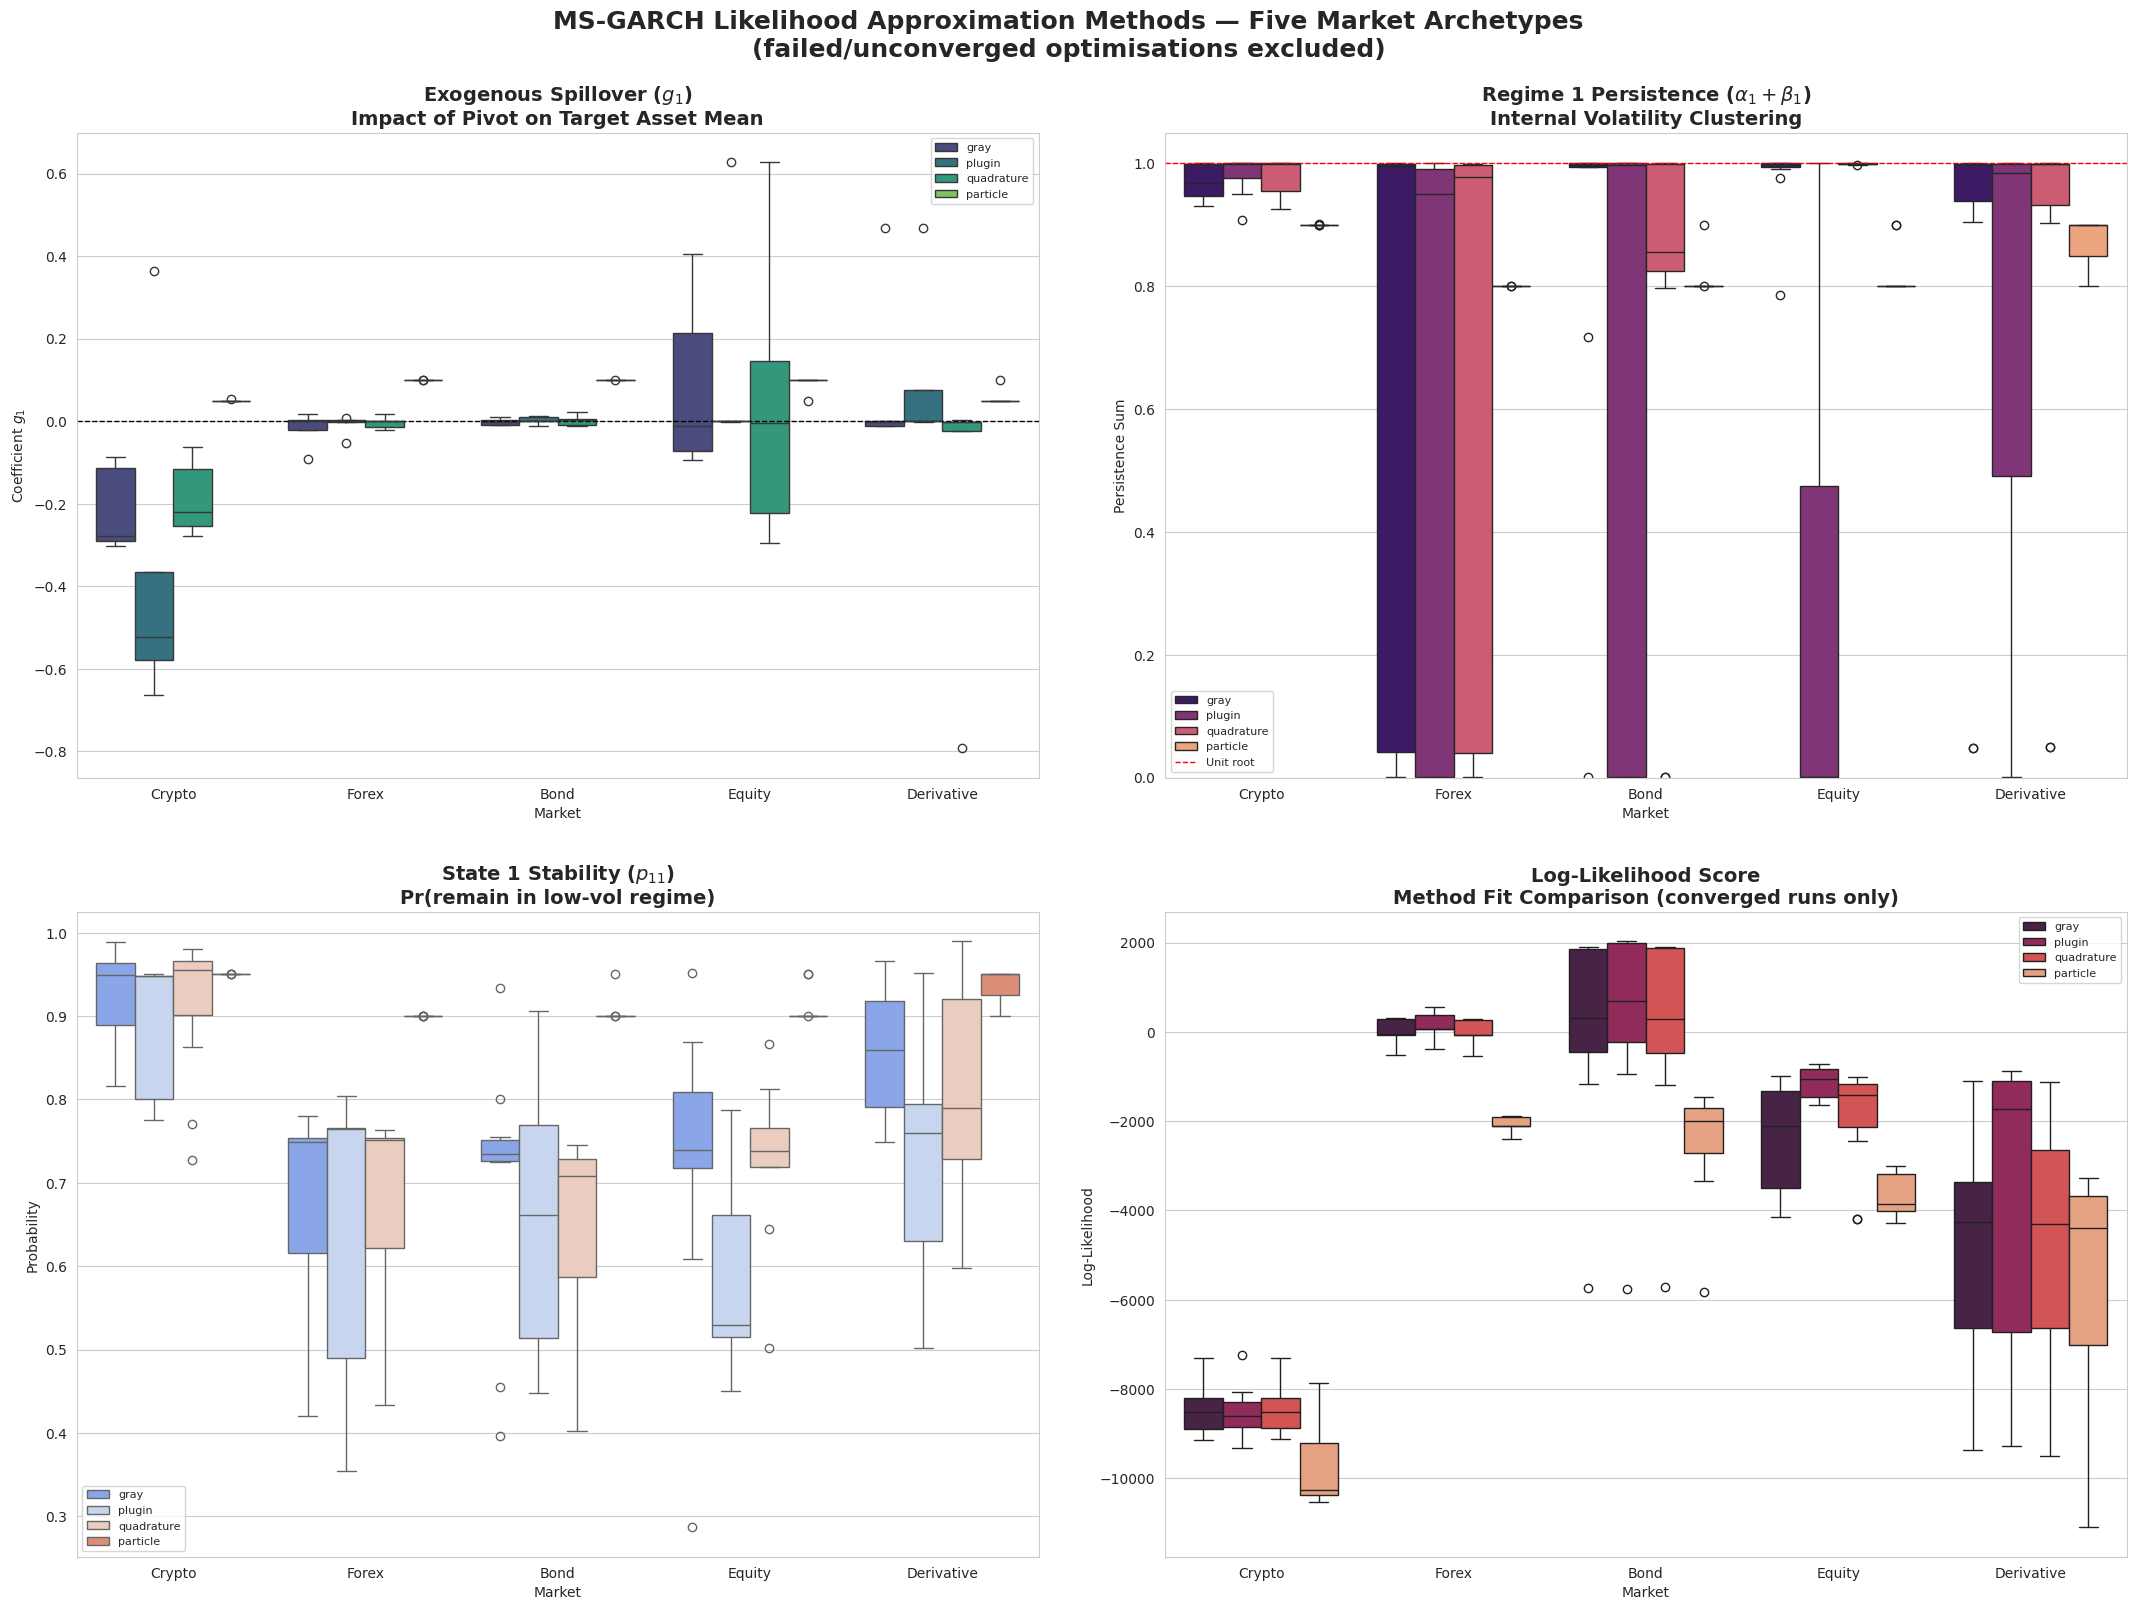

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# df already contains only converged runs (filtered in cell 10)
df['Persist_S1'] = df['a1'] + df['b1']

method_order = ['gray', 'plugin', 'quadrature', 'particle']
market_order = ['Crypto', 'Forex', 'Bond', 'Equity', 'Derivative']

df_exo = df[df['Has_Exo'] == True]

plt.figure(figsize=(22, 16))
sns.set_style("whitegrid")

# ── Subplot 1: Spillover g1 (exogenous runs only) ─────────────────────────
plt.subplot(2, 2, 1)
sns.boxplot(data=df_exo, x='Market', y='g1',
            hue='Method', hue_order=method_order, order=market_order, palette='viridis')
plt.title("Exogenous Spillover ($g_1$)\nImpact of Pivot on Target Asset Mean",
          fontsize=14, fontweight='bold')
plt.ylabel("Coefficient $g_1$")
plt.axhline(0, color='black', lw=1, ls='--')
plt.legend(fontsize=8)

# ── Subplot 2: Regime-1 persistence α1+β1 ────────────────────────────────
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Market', y='Persist_S1',
            hue='Method', hue_order=method_order, order=market_order, palette='magma')
plt.title("Regime 1 Persistence ($\\alpha_1 + \\beta_1$)\nInternal Volatility Clustering",
          fontsize=14, fontweight='bold')
plt.ylabel("Persistence Sum")
plt.ylim(0, 1.05)
plt.axhline(1.0, color='red', lw=1, ls='--', label='Unit root')
plt.legend(fontsize=8)

# ── Subplot 3: State-1 transition probability p11 ─────────────────────────
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Market', y='p11',
            hue='Method', hue_order=method_order, order=market_order, palette='coolwarm')
plt.title("State 1 Stability ($p_{11}$)\nPr(remain in low-vol regime)",
          fontsize=14, fontweight='bold')
plt.ylabel("Probability")
plt.legend(fontsize=8)

# ── Subplot 4: Log-Likelihood ─────────────────────────────────────────────
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Market', y='LogLik',
            hue='Method', hue_order=method_order, order=market_order, palette='rocket')
plt.title("Log-Likelihood Score\nMethod Fit Comparison (converged runs only)",
          fontsize=14, fontweight='bold')
plt.ylabel("Log-Likelihood")
plt.legend(fontsize=8)

plt.tight_layout(pad=3.0)
plt.suptitle(
    "MS-GARCH Likelihood Approximation Methods — Five Market Archetypes\n"
    "(failed/unconverged optimisations excluded)",
    y=1.02, fontsize=18, fontweight='bold'
)

plt.savefig("MSGARCH_Comparative_Analysis.png", dpi=300, bbox_inches='tight')
print("Figure saved: MSGARCH_Comparative_Analysis.png")
plt.show()
